In [2]:

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [3]:
def plot_data_fit(ax, df, m, popt):
    x_min = 1
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 2
    reshape_fac = 4
    ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

    ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8)
    ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="v", label="$\\mathcal{P}_{FF}$", color="#017517", alpha=0.8)
    P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
    P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
    ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="s", label="$\\mathcal{P}_{SF}+\\mathcal{P}_{FS}$", color=gs.get_color(3), alpha=0.8)
    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
    P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
    ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
    P0110_fit = P_fit[1] + P_fit[2]
    ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
    ax.set_ylabel("Populations")
    ax.legend(loc="upper right")
    ax.set_ylim(-0.05, 1.0)

    ax.set_xlim(x_min, x_max)
    
    ax.set_xscale("log")
    # place legend in upper right corner


C:\Users\webbd\AppData\Local\Temp\ipykernel_40148\1881907047.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\webbd\AppData\Local\Temp\ipykernel_40148\1881907047.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


<Figure size 640.944x166.479 with 0 Axes>

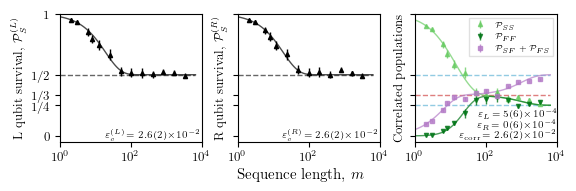

In [32]:
m = fh.SO3Model()

fig_width = gs.get_fig_width()*1.1
fig_height = gs.get_fig_width()/3.5

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(fig_width, fig_height))
fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True, gridspec_kw={"wspace": 0.25})

# Plot two qubit decays
date = "2026-02-05"
rid = 93319 # 10 kHz detuning dataset
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
x_min = 1
x_max = max(df["Clifford Length"]) * 2
sim_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
plot_data_fit(axs[2], df, m, popt)

# Plot single qubit decays
x, P_L, P_L_err, P_R, P_R_err = m.get_single_qubit_pops(df)
e_cL, e_cR = m.get_single_qubit_errors(popt)
spam = popt[3]
P_L_fit = [m.single_qubit_model(i, e_cL, spam) for i in sim_line]
P_R_fit = [m.single_qubit_model(i, e_cR, spam) for i in sim_line]
for ax, P, P_err, P_fit, label in zip([axs[0], axs[1]], [P_L, P_R], [P_L_err, P_R_err], [P_L_fit, P_R_fit], ["L qubit survival, $\\mathcal{P}_S^{(L)}$", "R qubit survival, $\\mathcal{P}_S^{(R)}$"]):
    ax.hlines(0.5, x_min, x_max, color="black", linestyle="--", alpha=0.6)
    ax.errorbar(df["Clifford Length"], P, yerr=P_err, fmt="^",color="black", alpha=1.0)
    ax.plot(sim_line, P_fit, color="black", alpha=gs.get_alpha(), linestyle="-")
    # turn off legend
    ax.legend().set_visible(False)
    ax.set_yticks([0, 1/4, 1/3, 1/2, 1.0])
    ax.set_yticklabels(["0", r"$1/4$",r"$1/3$", r"$1/2$", "1"])
    ax.set_ylabel(label)
    ax.set_xscale("log")


# Save the figure
# Optional: hide repeated tick labels
plt.setp(axs[1].get_yticklabels(), visible=False)
plt.setp(axs[2].get_yticklabels(), visible=False)
# remove grid lines
for ax in axs:
    ax.grid(False)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks([1, 100, 10000])


axs[2].set_ylabel("Correlated populations")
axs[0].text(0.98, 0.11, r"$\varepsilon^{(L)}_c\!= 2.6(2)\!\times\!10^{-2}$", transform=axs[0].transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right')
axs[1].text(0.98, 0.11, r"$\varepsilon^{(R)}_c\!= 2.6(2)\!\times\!10^{-2}$", transform=axs[1].transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right')
axs[2].text(0.99, 0.26, r"$\varepsilon_{L}\!= 5(6)\!\times\!10^{-4}$", transform=axs[2].transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right')
axs[2].text(0.99, 0.18, r"$\varepsilon_{R}\!= 0(6)\!\times\!10^{-4}$", transform=axs[2].transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right')
axs[2].text(0.99, 0.10, r"$\varepsilon_\mathrm{corr}\!= 2.6(2)\!\times\!10^{-2}$", transform=axs[2].transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right')
# axs[2].legend(loc="lower right", fontsize=9)
# raise supxlabel
fig.supxlabel("Sequence length, $m$", y=-0.125)
# plt.tight_layout()
# Print results
f_path = "..\\..\\pdf_figure\\ch5\\asymptotes_data.pdf"
plt.savefig(f_path, bbox_inches = "tight")

In [ ]:
# Parity scan inset
def unpack_parity(rid, day):
    f = fh.load_result(rid=rid, day=day, experiment="fastgates")
    print(f["datasets"].keys())
    try:
        x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])  # num cliffs
        y = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_1"])  # seed?
        z = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_2"])  # phase turns?

    except KeyError:
        x = None
        y = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])  # num cliffs
        z = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_1"])  # seed?

    parity = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_rbm_readout_parity"]
    )
    parity_err = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_rbm_readout_parity_err"]
    )
    p = parity, parity_err
    return x, y, z, p


def average_parity(seeds, phases, p):
    unique_seeds = np.sort(np.unique(seeds))
    unique_phases = np.sort(np.unique(phases))
    parity_array = np.zeros((len(unique_seeds), len(unique_phases)))
    err_array = np.zeros((len(unique_seeds), len(unique_phases)))

    for i, s in enumerate(unique_seeds):
        mask = seeds == s
        phases_scan = phases[mask]
        sort_ph = np.argsort(phases_scan)
        parity_array[i, :] = p[0][mask][sort_ph]
        err_array[i, :] = p[1][mask][sort_ph]
    avg_parity = np.mean(parity_array, axis=0)
    avg_err = np.sqrt(np.sum(err_array**2, axis=0)) / len(unique_seeds)
    return avg_parity, avg_err, unique_phases


def model_sin(x, a, b, c):
    return a * np.cos(2 * np.pi * x + b) + c


def fit_sin(x, y):
    # Initial guess for the parameters
    initial_guess = [0.5, 0.0, 0]
    limits = ([0, 0, 0], [1, 0.05, 0.05])  # Amplitude between 0 and 1

    # Fit the model to the data
    params, covariance = curve_fit(model_sin, x, y, p0=initial_guess, bounds=limits)

    return params, np.sqrt(np.diag(covariance))


def get_contrast(seeds, phases, p):
    avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
    params, params_err = fit_sin(unique_phases, avg_p)
    return 2 * params[0], 2 * params_err[0]


def plot_parity_scan_inset(rid, date):
    num_cliffs, seeds, phases, p = unpack_parity(rid, date)

    avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
    params, params_err = fit_sin(unique_phases, avg_p)
    factor = 1
    fig, ax = plt.subplots(figsize=(1.3*factor, 1*factor))
    ax.errorbar(unique_phases, avg_p, yerr=avg_err, fmt="o", color="black", label="Data")
    x_fit = np.linspace(min(unique_phases), max(unique_phases), 100)
    y_fit = model_sin(x_fit, *params)
    ax.plot(x_fit, y_fit, label="Fitted Sine Wave", color="black", linestyle="-")
    ax.set_yticks([-1/3, 0, 1/3], [r"$-\frac{1}{3}$", "0", r"$\frac{1}{3}$"])
    # x tickks at 0, 0.5, 1
    ax.set_xticks([0, 0.5, 1], ["0", "$\\pi$", "$2\\pi$"])
    ax.set_ylim(-1/3, 1/3)
    ax.set_xlim(0, 1)
    ax.set_xlabel("$\\phi$", labelpad=1)
    ax.set_ylabel("$\\Pi$", labelpad=-5)
    print("Fitted parameters:", params)
    print("Parameter errors:", params_err)
    ax.grid(False)
    return fig, ax, params, params_err



dict_keys(['ndscan.rid_93292.analysis_results', 'ndscan.rid_93292.annotations', 'ndscan.rid_93292.axes', 'ndscan.rid_93292.channels', 'ndscan.rid_93292.completed', 'ndscan.rid_93292.fragment_fqn', 'ndscan.rid_93292.ndscan_schema_revision', 'ndscan.rid_93292.online_analyses', 'ndscan.rid_93292.points.axis_0', 'ndscan.rid_93292.points.axis_1', 'ndscan.rid_93292.points.channel_crystal_check_readout_counts', 'ndscan.rid_93292.points.channel_crystal_check_readout_is_brights', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_00', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_01_10', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_11', 'ndscan.rid_93292.points.channel_crystal_check_readout_parity', 'ndscan.rid_93292.points.channel_crystal_check_readout_parity_err', 'ndscan.rid_93292.points.channel_expected_outcome', 'ndscan.rid_93292.points.channel_measurement_camera_readout_p', 'ndscan.rid_93292.points.channel_measurement_camera_readout_p_0', 'ndscan.rid_93292.poi

<Figure size 582.677x342.751 with 0 Axes>

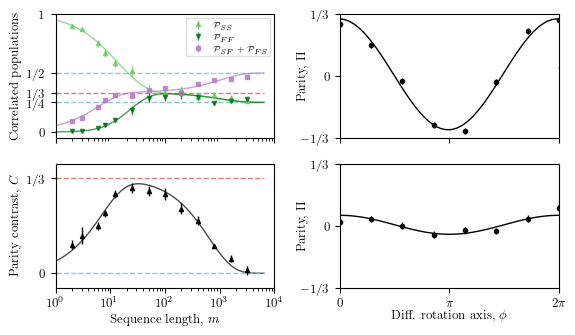

In [ ]:

m = fh.SO3Model()

fig_width = gs.get_fig_width()
fig_height = gs.get_fig_width()/1.7

fig = plt.figure(figsize=(fig_width, fig_height))
fig, axs_all = plt.subplots(2, 2, figsize=(fig_width, fig_height))
axs = axs_all.flatten()

# Plot two qubit decays
date = "2026-02-05"
rid = 93319 # 10 kHz detuning dataset
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
x_min = 1
x_max = max(df["Clifford Length"]) * 2
sim_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
plot_data_fit(axs[0], df, m, popt)


# Optional: hide repeated tick labels
plt.setp(axs[0].get_xticklabels(), visible=False)
plt.setp(axs[1].get_xticklabels(), visible=False)
# remove grid lines
for ax in [axs[0], axs[2]]:
    ax.grid(False)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks([1, 100, 10000])
    ax.set_ylabel("Correlated populations")

axs[2].set_xlabel("Sequence length, $m$", y=0.075)

# plot parities
# data from: 
cliffords = [50, 25, 12,  100, 200, 400, 800, 6, 3, 1600, 8, 2, 3200]
par_contrast = np.array([
    0.5738,
    0.5967,
    0.5525,
    0.5551,
    0.4517,
    0.3674,
    0.1941,
    0.3287,
    0.2634,
    0.1025,
    0.4192,
    0.1997,
    0.0213,
])*1/2
par_contrast_err = np.array([
    0.0343,
    0.0344,
    0.0273,
    0.0433,
    0.0373,
    0.0309,
    0.0118,
    0.0274,
    0.0577,
    0.0261,
    0.0268,
    0.0318,
    0.0304,
])*1/2

p_parity = axs[2].errorbar(cliffords, par_contrast, yerr=par_contrast_err, color="black", fmt="^")

depol_popt = popt[1] + popt[2]  # Total depolarizing error from the previous fit

popt_infer = [popt[0], depol_popt]  # Initial guess for l and g from the previous fit
# combine index 1 and 2 of the covariance matrix to get the variance for the total depolarizing error
pcov_infer_diagonal = np.diag([pcov[0, 0], pcov[1, 1] + pcov[2, 2] + 2*pcov[1, 2]])  # Variance for the initial guess
# get covariance between index 0 and the total depolarizing error by summing the covariances of index 0 with index 1 and index 2
pcov_infer_offdiag = pcov[0, 1] + pcov[0, 2]  # Covariance between l and the total depolarizing error
pcov_infer = np.array([[pcov_infer_diagonal[0, 0], pcov_infer_offdiag], [pcov_infer_offdiag, pcov_infer_diagonal[1, 1]]])  # Covariance matrix for the initial guess
popt_par, pcov_par = curve_fit(m.parity_model, cliffords, par_contrast, p0=popt_infer)

# fitted_parity_decay = m.parity_model(sim_line, *popt_infer)
fitted_parity_par = m.parity_model(sim_line, *popt_par)
# plot error bars for the fit by shading the area between the upper and lower bounds of the fit using MC method
# best-fit parameters and covariance from your fit
# draw correlated parameter samples
n_samples = 5000
#param_samples = np.random.multivariate_normal(popt_infer, pcov_infer, size=n_samples)
param_samples = np.random.multivariate_normal(popt_par, pcov_par, size=n_samples)

# evaluate model for each sample
y_samples = np.array([m.parity_model(sim_line, *p) for p in param_samples])

# central 68% band, roughly 1-sigma
y_lo = np.percentile(y_samples, 16, axis=0)
y_hi = np.percentile(y_samples, 84, axis=0)

axs[1].fill_between(sim_line, y_lo, y_hi, alpha=0.4, color="gray")

axs[2].plot(sim_line, fitted_parity_par, color="black", alpha=gs.get_alpha(), linestyle="-")
axs[2].hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
axs[2].hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
axs[2].set_ylabel("Parity contrast, $C$")
axs[2].set_ylim(-0.05, 1/3+0.05)
axs[2].set_yticks([0, 1/3])
axs[2].set_yticklabels(["0", r"$\frac{1}{3}$"])
axs[2].set_xlabel("Sequence length, $m$")

axs[0].set_yticks([0, 1/4, 1/3, 1/2, 1.0])
axs[0].set_yticklabels(["0", r"$1/4$",r"$1/3$", r"$1/2$", "1"])
axs[2].set_yticks([0, 1/3])
axs[2].set_yticklabels(["0", r"$1/3$"])
axs[2].set_xscale("log")

# parity scan
date = "2026-02-05"

rid = 93292 # 25 cliffs
num_cliffs, seeds, phases, p = unpack_parity(rid, date)
avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
params, params_err = fit_sin(unique_phases, avg_p)
axs[1].set_xscale("linear")
axs[1].errorbar(unique_phases, avg_p, yerr=avg_err, fmt="o", color="black", label="Data")
x_fit = np.linspace(min(unique_phases), max(unique_phases), 100)
y_fit = model_sin(x_fit, *params)
axs[1].plot(x_fit, y_fit, label="Fitted Sine Wave", color="black", linestyle="-")
axs[1].set_yticks([-1/3, 0, 1/3], [r"$-1/3$", "0", r"$1/3$"])
axs[1].set_xticks([0, 0.5, 1], ["0", "$\\pi$", "$2\\pi$"])
axs[1].set_ylim(-1/3, 1/3)
axs[1].set_xlim(0, 1)
axs[1].set_ylabel("Parity, $\\Pi$", labelpad=-5)
axs[1].grid(False)


rid = 93307 # 1600 cliffs
num_cliffs, seeds, phases, p = unpack_parity(rid, date)
avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
params, params_err = fit_sin(unique_phases, avg_p)
axs[3].set_xscale("linear")
axs[3].errorbar(unique_phases, avg_p, yerr=avg_err, fmt="o", color="black", label="Data")
x_fit = np.linspace(min(unique_phases), max(unique_phases), 100)
y_fit = model_sin(x_fit, *params)
axs[3].plot(x_fit, y_fit, label="Fitted Sine Wave", color="black", linestyle="-")
axs[3].set_yticks([-1/3, 0, 1/3], [r"$-1/3$", "0", r"$1/3$"])
axs[3].set_xticks([0, 0.5, 1], ["0", "$\\pi$", "$2\\pi$"])
axs[3].set_ylim(-1/3, 1/3)
axs[3].set_xlim(0, 1)
axs[3].set_xlabel("Diff. rotation axis, $\\phi$", labelpad=1)
axs[3].set_ylabel("Parity, $\\Pi$", labelpad=-5)
axs[3].grid(False)

plt.tight_layout()
f_path = "..\\..\\pdf_figure\\ch4\\parity_data.pdf"
plt.savefig(f_path, bbox_inches = "tight")